# Week 5 NLP: Analyst 1 — text cleaning and length analysis

**Owner:** Zheng Wei. 
**Deliverables:** tested `clean_text()` / `build_text_payload()` in the adjacent `preprocess.py`, and a training-text distribution with a `max_length` recommendation.

This notebook uses original `title`, `purpose`, and `desc`. Employment title is audited as an optional additional field. `emp_length` stays structured. The dummy-batch `synthetic_desc` file is not loaded.

**Source status:** the downloaded ZIP differs from the archive hash in the frozen split metadata. The loader verifies row count, one-based source-record mapping, issue months, labels and original description availability. Passing these checks permits provisional development EDA; it does not establish byte-for-byte equivalence to the team's frozen archive. Confirm the source with the data owner before treating the recommendation as final.

Run all cells in order with the **credit-engine-nlp** Python environment. Setup, if needed: `python -m pip install -r src/nlp/requirements.txt` from the repository root. The first tokenization run downloads tokenizer/config files only. Raw data, tokenizer cache and generated reports remain in Git-ignored directories.


## 1. Setup and source contract

The manifest's `source_row_number` counts parsed CSV data records from **1** (excluding the header). Do not use zero-based DataFrame indexes directly, count physical text lines, drop records, or sort the CSV before assigning these numbers.

The existing split assignments and targets are consumed unchanged. No random split is created. The default run uses training text only; validation confirmation is an optional later step. The loader does not expose the final test split.


In [1]:
from pathlib import Path
import os
import sys
import json
import platform
from importlib.metadata import version

cwd = Path.cwd().resolve()
ROOT = next(
    (p for p in (cwd, *cwd.parents) if (p / "data" / "split_manifest.csv").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the instant-checkout-credit-engine repository.")
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
DATA_DIR = ROOT / "data"
OUTPUT_DIR = DATA_DIR / "processed" / "nlp"
CACHE_DIR = DATA_DIR / "external" / "huggingface"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(DATA_DIR / "external" / "matplotlib"))
os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from src.nlp.preprocess import (
    CORE_TEXT_COLUMNS, PREPROCESS_VERSION, audit_source_files,
    build_text_payload, clean_text, load_original_split,
)

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "font.size": 10,
})
versions = {
    "python": platform.python_version(),
    **{name: version(name) for name in ["pandas", "numpy", "matplotlib", "transformers", "tokenizers"]},
}
print(json.dumps(versions, indent=2))


{
  "python": "3.14.6",
  "pandas": "3.0.5",
  "numpy": "2.5.3",
  "matplotlib": "3.11.2",
  "transformers": "5.17.0",
  "tokenizers": "0.23.2"
}


In [2]:
source_audit = audit_source_files(DATA_DIR)
print(json.dumps(source_audit, indent=2))
if not source_audit["archive_matches"]:
    display(Markdown(
        "**Provisional EDA:** the downloaded archive hash does not match the frozen metadata "
        "(or the ZIP is absent). Preserve the recorded hashes and obtain source confirmation. "
        "The next cell independently validates the selected rows."
    ))


{
  "dataset_version": "kaggle-adarshsng-local-2026-09-09",
  "split_version": "split-v1",
  "preprocess_version": "nlp-preprocess-v1",
  "expected_archive_sha256": "c6255f6a8099b25303360976597fd8f86ae9087176598692a5a37dd8dc3339a1",
  "actual_archive_sha256": "e5de55438920e393443d6212946cd6a0954664e952cdb3683c5607c8beb192f1",
  "archive_matches": false,
  "raw_csv_sha256": "23783ef320e4df24ac113d6e5b830edb909912b7783d49b89aacd5690dc9120c",
  "manifest_sha256": "41686f71f2534616e565b5ea7b78873cd2222f5079b235c179942192ac898e48"
}


**Provisional EDA:** the downloaded archive hash does not match the frozen metadata (or the ZIP is absent). Preserve the recorded hashes and obtain source confirmation. The next cell independently validates the selected rows.

In [3]:
# Load emp_title for its missingness and optional length comparison.
# The main payload is explicitly rebuilt with the agreed core fields.
train = load_original_split(DATA_DIR, split="train", include_emp_title=True)
train["text_payload"] = [
    build_text_payload(row)
    for row in train[list(CORE_TEXT_COLUMNS)].to_dict(orient="records")
]
train["text_payload_with_emp_title"] = [
    build_text_payload(row, include_emp_title=True)
    for row in train[[*CORE_TEXT_COLUMNS, "emp_title"]].to_dict(orient="records")
]
assert train["split"].eq("train").all() # The split column is a sanity check for the frozen split.
assert train["loan_id"].is_unique
assert train["text_payload"].str.len().gt(0).all() # The text payload should not be empty.
assert train["text_payload_with_emp_title"].str.len().gt(0).all() # The text payload with emp_title should not be empty.
print(f"Loaded {len(train):,} training rows with validated one-based mapping.")
print(f"Issue-month range: {train['issue_month'].min()} to {train['issue_month'].max()}")


Loaded 86,293 training rows with validated one-based mapping.
Issue-month range: 2007-06 to 2013-07


## 2. Missingness and cleaning

Missing scalars and explicit missing markers become empty strings. Missing fields are omitted from the payload. Cleaning normalizes Unicode, HTML and whitespace, and removes the known “Borrower added on date” wrapper. It preserves case, punctuation, numbers and negation. The shared preprocessing does not stem, remove stop words or truncate.

`purpose` is categorical text: its underscores become spaces in the payload. The fixed field order is Title → Purpose → Description, optionally followed by Employment title. Labels and repayment fields are used only for mapping validation.

The CSV loader preserves empty cells and missing markers as strings for this audit, so pandas null_count can be zero even when text is missing. Use blank_or_marker_after_cleaning and missing_percent to assess usable text. Records whose descriptions become empty after cleaning are retained with their remaining original fields.

This selected cohort already requires an original description. Its missingness rates must not be generalized to all 2.26 million source loans. Outputs below are aggregates; no borrower descriptions or employer names are displayed.


In [4]:
# Handwritten example only; not a row from loan.csv or the supplied synthetic file.
example = {
    "title": "  Paying down cards ",
    "purpose": "debt_consolidation",
    "desc": "Borrower added on 01/01/13 > I do not want more debt.<br />A &amp; B.",
    "emp_title": None,
    "synthetic_desc": "Excluded dummy data",
    "target": 1,
}
print(build_text_payload(example))
assert clean_text(None) == ""
assert clean_text(float("nan")) == ""
assert "Excluded dummy data" not in build_text_payload(example)


Title: Paying down cards
Purpose: debt consolidation
Description: I do not want more debt. A & B.


In [5]:
fields = [*CORE_TEXT_COLUMNS, "emp_title"]
cleaned_fields = train[fields].apply(lambda col: col.map(clean_text)) # cleaned_fields are the payload-ready values, with missing values as empty strings
missingness = pd.DataFrame({
    "null_count": train[fields].isna().sum(),
    "blank_or_marker_after_cleaning": cleaned_fields.eq("").sum(), # count of rows that are empty after cleaning, including missing values and known missing markers
    "missing_percent": cleaned_fields.eq("").mean() * 100, 
})
display(missingness.round(3))
duplicate_payloads = int(train["text_payload"].duplicated().sum())
print(f"Repeated core payloads after their first occurrence: {duplicate_payloads:,}")
print("IDs and frozen cohort rows are retained; duplicate text does not automatically imply duplicate loans.")


,null_count,blank_or_marker_after_cleaning,missing_percent
title,0,11,0.013
purpose,0,0,0.000
desc,0,9,0.010
emp_title,0,5283,6.122


Repeated core payloads after their first occurrence: 1,441
IDs and frozen cohort rows are retained; duplicate text does not automatically imply duplicate loans.


### 2.1 What each text column contributes

| Column | Meaning in this analysis | Treatment in the shared payload using `clean_text` |
| --- | --- | --- |
| `title` | A short loan title. It can repeat the purpose, but may add borrower wording. | Clean and include when present. |
| `purpose` | A categorical loan-purpose label, not a free-form paragraph. | Include as text, replacing underscores with spaces. |
| `desc` | The original borrower description, sometimes containing dated entry prefixes and HTML formatting. | Clean formatting and known prefixes, preserving the remaining prose. |
| `emp_title` | An employment-title field that can contain employer names or other inconsistent free text. | Audit separately; opt-in only, not part of the core recommendation. |

`synthetic_desc` in `synthetic_descriptions_v2.csv` is dummy testing data and is excluded. IDs, targets and repayment outcomes never enter the text payload.

All following percentages refer to the selected **training cohort**, not the complete Kaggle dataset. This cohort was selected for raw description availability, which explains why missingness here is unusually low.


In [6]:
import html
import re
import unicodedata
from src.nlp.preprocess import _BORROWER_WRAPPER

# Keep raw, generally cleaned, and payload-ready values separate.
raw_fields = train[fields].fillna("")
payload_fields = cleaned_fields.copy()
payload_fields["purpose"] = payload_fields["purpose"].str.replace("_", " ", regex=False).str.split().str.join(" ") # split and 
raw_field_words = raw_fields.apply(lambda col: col.str.split().str.len())
field_words = payload_fields.apply(lambda col: col.str.split().str.len()) # count words in each payload field

field_quality = pd.DataFrame({
    "usable_rows": payload_fields.ne("").sum(),
    "empty_rows": payload_fields.eq("").sum(),
    "empty_percent": payload_fields.eq("").mean() * 100,
    "unique_nonempty": payload_fields.apply(lambda col: col[col.ne("")].nunique()),
    "changed_by_clean_text": raw_fields.ne(cleaned_fields).sum(),
    "changed_for_payload": raw_fields.ne(payload_fields).sum(),
})
display(field_quality.round(3))

# Length summaries use NONEMPTY payload-ready values only; raw medians use those same rows. Purpose therefore counts "debt consolidation" as 2 words.
length_rows = []
for field in fields:
    usable = payload_fields[field].ne("") # only count rows that are nonempty after cleaning for the length summaries
    words = field_words.loc[usable, field]
    length_rows.append({
        "column": field,
        "usable_rows": int(usable.sum()),
        "raw_median_words": raw_field_words.loc[usable, field].median(),
        "clean_median_words": words.median(),
        "clean_p95_words": words.quantile(0.95),
        "clean_p99_words": words.quantile(0.99),
        "clean_max_words": words.max(),
    })
field_word_summary = pd.DataFrame(length_rows).set_index("column")
display(field_word_summary.round(2))

# Format indicators are overlapping pattern counts, not mutually exclusive error categories. Tag/entity patterns are heuristics, not an HTML validator.
html_tag_pattern = r"</?[A-Za-z][^>]*>"
entity_pattern = r"&(?:#[0-9]+|#x[0-9A-Fa-f]+|[A-Za-z][A-Za-z0-9]+);"
normalized_fields = raw_fields.apply(
    lambda col: col.map(lambda value: html.unescape(unicodedata.normalize("NFKC", value)))
)
wrapper_counts = normalized_fields.apply(lambda col: col.str.count(_BORROWER_WRAPPER))
formatting_counts = pd.DataFrame({
    "borrower_wrapper_rows": wrapper_counts.gt(0).sum(),
    "html_tag_pattern_rows": raw_fields.apply(lambda col: col.str.contains(html_tag_pattern).sum()),
    "html_entity_pattern_rows": raw_fields.apply(lambda col: col.str.contains(entity_pattern).sum()),
    "extra_whitespace_rows": raw_fields.apply(lambda col: col.ne(col.str.split().str.join(" ")).sum()),
    "unicode_nfkc_changed_rows": raw_fields.apply(
        lambda col: col.ne(col.map(lambda value: unicodedata.normalize("NFKC", value))).sum()
    ),
})
display(formatting_counts)

desc_wrapper_counts = wrapper_counts["desc"]
wrapped_desc = desc_wrapper_counts.gt(0)
desc_without_wrappers = normalized_fields["desc"].str.replace(_BORROWER_WRAPPER, "", regex=True)
wrapper_words_removed = (
    normalized_fields["desc"].str.split().str.len()
    - desc_without_wrappers.str.split().str.len()
)
wrapper_audit = {
    "rows_with_wrapper": int(wrapped_desc.sum()),
    "percent_of_training_rows": 100 * float(wrapped_desc.mean()),
    "total_wrapper_occurrences": int(desc_wrapper_counts.sum()),
    "rows_with_multiple_wrappers": int(desc_wrapper_counts.gt(1).sum()),
    "wrapped_rows_empty_after_cleaning": int((wrapped_desc & cleaned_fields["desc"].eq("")).sum()),
    "unwrapped_rows_empty_after_cleaning": int((~wrapped_desc & cleaned_fields["desc"].eq("")).sum()),
    "median_wrapper_words_removed_in_wrapped_rows": float(wrapper_words_removed[wrapped_desc].median()),
}
print(json.dumps(wrapper_audit, indent=2))
description_cleaning_impact = {
    "raw_whitespace_words": int(raw_field_words["desc"].sum()),
    "clean_whitespace_words": int(field_words["desc"].sum()),
    "net_word_reduction_percent": 100 * float(
        1 - field_words["desc"].sum() / raw_field_words["desc"].sum()
    ),
}
print(json.dumps(description_cleaning_impact, indent=2))

# This is descriptive overlap, not a feature-importance or predictive test.
canonical_title = payload_fields["title"].str.casefold().str.replace("_", " ", regex=False).str.split().str.join(" ")
canonical_purpose = payload_fields["purpose"].str.casefold()
title_purpose_overlap = int((canonical_title.eq(canonical_purpose) & canonical_title.ne("")).sum())
title_nonempty_rows = int(canonical_title.ne("").sum())
print(f"Titles exactly matching purpose after case/underscore normalization: {title_purpose_overlap:,} / {title_nonempty_rows:,} nonempty titles")
assert field_quality["usable_rows"].add(field_quality["empty_rows"]).eq(len(train)).all()


,usable_rows,empty_rows,empty_percent,unique_nonempty,changed_by_clean_text,changed_for_payload
title,86282,11,0.013,30844,3101,3101
purpose,86293,0,0.000,14,0,75081
desc,86284,9,0.010,81897,84407,84407
emp_title,81010,5283,6.122,58976,2757,2757


,usable_rows,raw_median_words,clean_median_words,clean_p95_words,clean_p99_words,clean_max_words
column,,,,,,
title,86282,2.0,2.0,5.0,7.0,18
purpose,86293,1.0,2.0,2.0,2.0,2
desc,86284,34.0,29.0,132.0,270.0,790
emp_title,81010,3.0,3.0,5.0,6.0,11


,borrower_wrapper_rows,html_tag_pattern_rows,html_entity_pattern_rows,extra_whitespace_rows,unicode_nfkc_changed_rows
title,0,0,0,3092,0
purpose,0,0,0,0,0
desc,79657,80301,2674,84261,19
emp_title,0,0,2,2740,3


{
  "rows_with_wrapper": 79657,
  "percent_of_training_rows": 92.30992085105397,
  "total_wrapper_occurrences": 101986,
  "rows_with_multiple_wrappers": 15818,
  "wrapped_rows_empty_after_cleaning": 5,
  "unwrapped_rows_empty_after_cleaning": 4,
  "median_wrapper_words_removed_in_wrapped_rows": 5.0
}
{
  "raw_whitespace_words": 4219043,
  "clean_whitespace_words": 3725068,
  "net_word_reduction_percent": 11.708223879206725
}
Titles exactly matching purpose after case/underscore normalization: 17,471 / 86,282 nonempty titles


### 2.2 What the training data tells us

The following observations describe the saved run of **86,293 training loans**. Recompute the tables and update this interpretation if the source or cleaning policy changes. Length percentiles refer to nonempty, payload-ready field values.


**Columns & Their Respective Findings:**

**`title`: short supplementary context.** Only **11 titles** are empty after cleaning. There are **30,844 distinct nonempty titles**, with a median of **2 words**, a 95th percentile of **5**, and a maximum of **18**. After case, underscore and whitespace normalization, **17,471 of 86,282 nonempty titles (20.25%)** exactly match the purpose. This shows partial redundancy, not that all titles are redundant. Keep the title as agreed, but leave claims about predictive benefit to a later model comparison. Most detected title formatting is extra whitespace (**3,092 rows**); no borrower wrappers or tag/entity patterns were detected.

**`purpose`: categorical text, not a narrative.** All training rows have a usable purpose, with only **14 distinct categories**. Debt consolidation and credit card together account for **74.71%** of the cohort. Repeated categories are expected, not duplicate-record errors. Replace underscores with spaces: `debt_consolidation` becomes `debt consolidation`. Its word count changes from one whitespace item to two without adding information. In this cohort the prepared labels have a median and maximum of **2 words**. The table below shows the category distribution; these counts are not default rates or measures of feature importance.

**`description`: the main variable-length narrative.** The cleaned description has a median of **29 words**, a 95th percentile of **132**, a 99th percentile of **270**, and a maximum of **790**. That long tail is why the model-token distribution matters more than the average alone. **9 descriptions** become empty after cleaning: **5 have a wrapper but no usable prose**, and **4 are unwrapped missing-marker values**. Retain all nine loans in the frozen split and build their payload from the other available fields. Do not invent or substitute a description.

**`employment_title`: optional, inconsistent free text.** **5,283 values (6.12%)** are empty after cleaning. The remaining **81,010 values** contain **58,976 distinct strings**, with a median of **3 words** and a maximum of **11**. That high number of distinct strings should not be mistaken for 58,976 standardized occupations. The field can hold employer names or other free text, and extra whitespace is detected in **2,740 rows**. Keep it opt-in; the core narrative and default token recommendation do not use it. Any benefit from including it requires a later controlled model comparison. No employer names are displayed here.

The combined-payload distributions later include **every training loan**, even when one field becomes empty. Repeated text is retained because identical wording does not establish that two loans are duplicates.


In [7]:
# Only categorical purpose labels are displayed, not borrower/employer text.
purpose_counts = payload_fields["purpose"].value_counts().rename_axis("purpose").to_frame("training_rows")
purpose_counts["percent_of_training_rows"] = purpose_counts["training_rows"] / len(train) * 100
display(purpose_counts.round(3))
assert purpose_counts["training_rows"].sum() == len(train)


,training_rows,percent_of_training_rows
purpose,,
debt consolidation,48439,56.133
credit card,16029,18.575
home improvement,5432,6.295
other,5313,6.157
major purchase,2659,3.081
small business,2405,2.787
car,1699,1.969
wedding,1193,1.382
medical,849,0.984


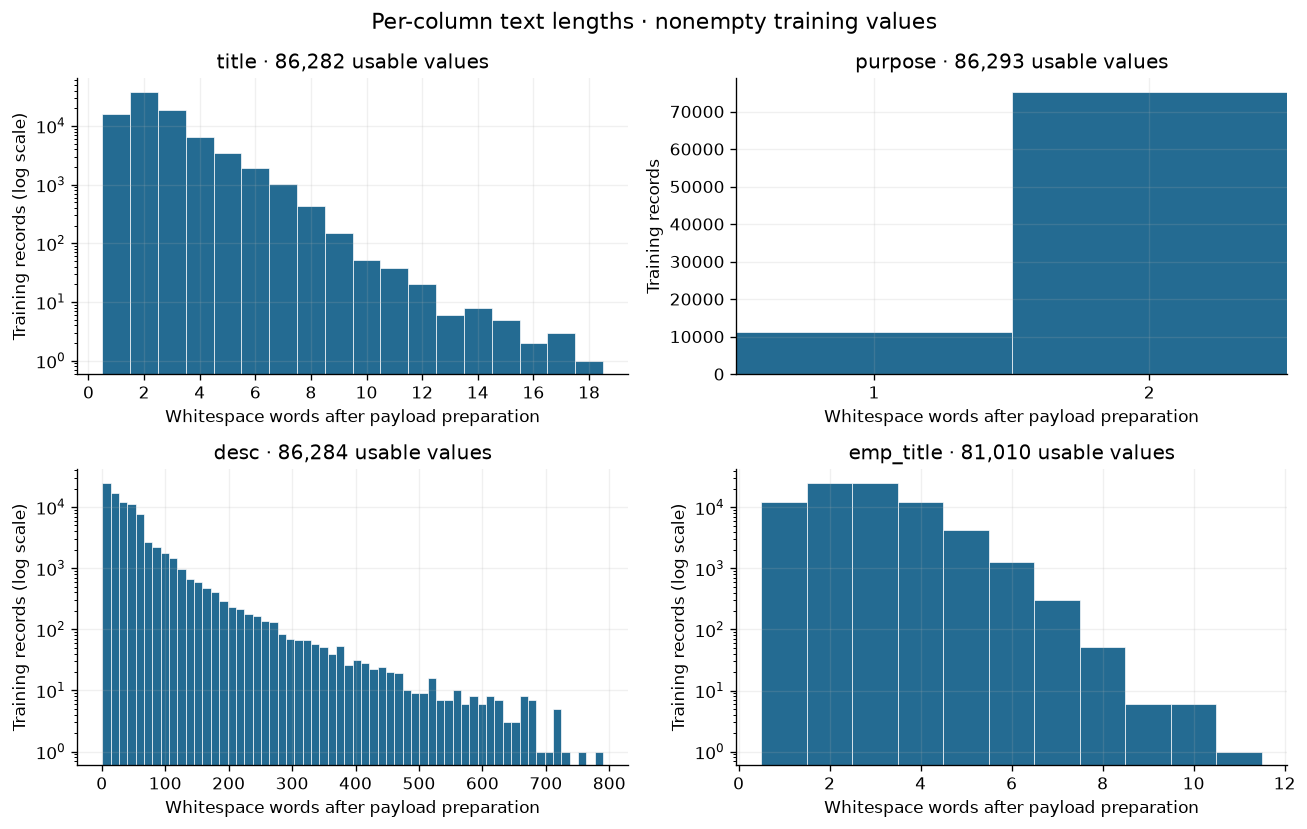

In [8]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, field in zip(axes.flat, fields):
    counts = field_words.loc[payload_fields[field].ne(""), field]
    # Integer-aligned bins for short fields; bounded bins for the long tail.
    bins = np.arange(0.5, int(counts.max()) + 1.5) if counts.max() <= 30 else 60
    ax.hist(counts, bins=bins, color="#246B92", edgecolor="white", linewidth=0.4)
    if field == "purpose":
        # Only one- and two-word categories: ordinary counts are clearest.
        ax.set_xticks([1, 2])
        ax.set_xlim(0.5, 2.5)
        ax.set_ylabel("Training records")
        ax.ticklabel_format(axis="y", style="plain")
    else:
        ax.set_yscale("log")
        ax.set_ylabel("Training records (log scale)")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(title=f"{field} · {len(counts):,} usable values",
           xlabel="Whitespace words after payload preparation")
fig.suptitle("Per-column text lengths · nonempty training values", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "column_word_lengths.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)


### 2.3 Why remove the borrower wrapper and other formatting?

A **borrower wrapper** is a known prefix such as `Borrower added on 01/01/13 >`. It marks a dated entry around the prose. A description can contain more than one entry, so the cleaner removes each matching prefix and joins the remaining text in its original order. It does **not** delete the whole description or every date.

In this training cohort, **79,657 descriptions (92.31%)** contain a wrapper, with **101,986 occurrences** in total. **15,818 descriptions** have multiple wrappers. Formatting is also common: **80,301 descriptions (93.06%)** match the HTML-tag pattern, **2,674 (3.10%)** match an entity pattern, and **84,261 (97.65%)** contain extra whitespace. These measured patterns motivate the cleaning rules rather than assuming every string needs the same correction.

| Cleaning choice | Why it is applied | What remains |
| --- | --- | --- |
| Remove the specific dated borrower prefix | Repeated entry labels inflate word/token counts and add administrative timestamps to the narrative. | The prose after each prefix, in order. |
| Decode HTML entities and remove HTML tags | `&amp;` and `<br />` are storage/display formatting. | Readable characters and spaces between text blocks. Script/style contents are omitted. |
| Normalise Unicode and whitespace | Visually equivalent characters, repeated spaces and line breaks can create inconsistent inputs. | A consistently spaced text string. |
| Convert missing values and exact missing markers to empty strings | Literal `nan` or `None` should not become borrower content. | Other available fields; no imputed narrative and no automatic row deletion. |
| Replace underscores in `purpose` | The underscores separate words in a category label. | The same category written with spaces. |
| Preserve case, punctuation, numbers and negation | Aggressive deletion can change meaning, especially phrases such as “do not”. | The shared original wording after formatting cleanup. The uncased tokenizer applies its own model-specific normalization later. |

All description cleaning combined reduces the whitespace word total from **4,219,043 to 3,725,068 (11.71%)**. This includes HTML, wrapper, whitespace and missing-value handling; do not attribute the whole reduction to wrappers. The isolated wrapper reduction printed above is also a whitespace-word measure, **not** a tokenizer count.

The pattern indicators overlap, so their counts cannot be added to obtain a number of “bad rows”. Removing timestamp prefixes does not prove when the remaining prose was available; that still depends on the source's prediction-time definition. The cleaner also does not anonymize personal information.


In [9]:
# All examples are handwritten illustrations, not actual borrower records.
cleaning_examples = [
    ("Borrower prefix", "Borrower added on 01/01/13 > I do not want more debt."),
    ("Multiple entries", "Borrower added on 01/01/13 > Repairs. Borrower added on 01/02/13 > No additional borrowing."),
    ("HTML and spacing", "  A &amp; B.<br />  No new debt. "),
    ("Unicode width", "Ｃａｒ repairs."),
    ("Ordinary date retained", "I started work on 01/01/13."),
    ("Missing marker", "None"),
    ("Wrapper without prose", "Borrower added on 01/01/13 >"),
]
examples_table = pd.DataFrame([
    {"case": label, "before": before, "after": clean_text(before) or "(empty)"}
    for label, before in cleaning_examples
])
with pd.option_context("display.max_colwidth", None):
    display(examples_table)
assert clean_text("I started work on 01/01/13.") == "I started work on 01/01/13."
assert clean_text(cleaning_examples[-1][1]) == ""


,case,before,after
0,Borrower prefix,Borrower added on 01/01/13 > I do not want more debt.,I do not want more debt.
1,Multiple entries,Borrower added on 01/01/13 > Repairs. Borrower added on 01/02/13 > No additional borrowing.,Repairs. No additional borrowing.
2,HTML and spacing,A &amp; B.<br /> No new debt.,A & B. No new debt.
3,Unicode width,Ｃａｒ repairs.,Car repairs.
4,Ordinary date retained,I started work on 01/01/13.,I started work on 01/01/13.
5,Missing marker,None,(empty)
6,Wrapper without prose,Borrower added on 01/01/13 >,(empty)


## 3. Word-count distributions

A word here means a whitespace-separated item. Payload counts include the field labels. This provides the brief's word-count plot; the tokenizer section then measures the actual model input length.


,count,mean,std,min,50%,90%,95%,99%,max
original_desc_cleaned,86293.0,43.17,53.36,0.0,29.0,93.0,132.0,270.00,790.0
core_payload,86293.0,50.54,53.69,3.0,36.0,100.0,140.0,278.08,797.0
with_emp_title,86293.0,54.97,53.77,6.0,41.0,105.0,144.0,283.00,803.0


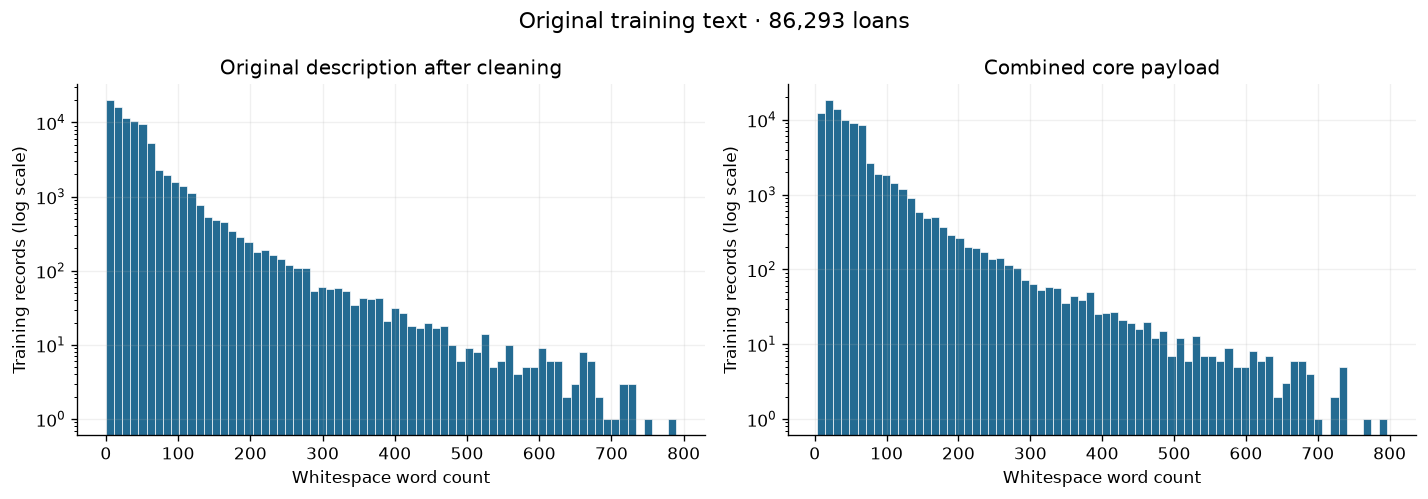

In [10]:
word_counts = pd.DataFrame({
    "original_desc_cleaned": cleaned_fields["desc"].str.split().str.len(),
    "core_payload": train["text_payload"].str.split().str.len(),
    "with_emp_title": train["text_payload_with_emp_title"].str.split().str.len(),
})
word_summary = word_counts.describe(percentiles=[0.50, 0.90, 0.95, 0.99]).T
display(word_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, title in zip(
    axes, ["original_desc_cleaned", "core_payload"],
    ["Original description after cleaning", "Combined core payload"],
):
    ax.hist(word_counts[col], bins=70, color="#246B92", edgecolor="white", linewidth=0.4)
    ax.set(title=title, xlabel="Whitespace word count", ylabel="Training records (log scale)")
    ax.set_yscale("log")
fig.suptitle(f"Original training text · {len(train):,} loans", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "word_lengths.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)


## 4. Actual DistilBERT token lengths

### Words, tokens and `max_length`

What we mean here by “max tokens” is the **maximum input sequence length**, configured as `max_length`. It is not a generated-output budget such as `max_tokens`.

- A word is a whitespace-separated item in the earlier plots. 
- A model token can be a whole word, a word fragment, or punctuation. 
The number of words therefore does not directly determine the number of tokens. We measure the actual tokenizer output on the **complete cleaned payload**, with `truncation=False` and `padding=False`, so the EDA can see the original length of long examples.

The pinned DistilBERT tokenizer surrounds a single narrative with `[CLS]` and `[SEP]`. Both count toward `max_length`. Thus, a cap of **384 total tokens** leaves up to **382 payload tokens**, including the `Title:`, `Purpose:` and `Description:` labels. Its model configuration supports **512 total input positions**. The following cell verifies these settings from the cached files rather than estimating from word counts.

Use the same tokenizer revision with Vincent (Analyst 3). Only tokenizer/configuration files are downloaded; all loan text stays local. The shared cleaner preserves case, but this **uncased** tokenizer performs its own lowercasing.

Reference: [Hugging Face DistilBERT documentation](https://huggingface.co/docs/transformers/model_doc/distilbert).


In [11]:
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer

TOKENIZER_ID = "distilbert/distilbert-base-uncased"
TOKENIZER_REVISION = "12040accade4e8a0f71eabdb258fecc2e7e948be"
snapshot = Path(snapshot_download(
    repo_id=TOKENIZER_ID,
    revision=TOKENIZER_REVISION,
    allow_patterns=["tokenizer.json", "tokenizer_config.json", "vocab.txt", "config.json"],
    cache_dir=str(CACHE_DIR),
))
tokenizer = AutoTokenizer.from_pretrained(str(snapshot), use_fast=True, local_files_only=True)
assert tokenizer.is_fast
config = json.loads((snapshot / "config.json").read_text(encoding="utf-8"))
MODEL_LIMIT = int(config["max_position_embeddings"])
SPECIAL_TOKENS = tokenizer.num_special_tokens_to_add(pair=False)
print(f"Tokenizer: {TOKENIZER_ID}")
print(f"Revision: {snapshot.name}")
print(f"Positional limit: {MODEL_LIMIT}; special tokens per sequence: {SPECIAL_TOKENS}")


/opt/anaconda3/envs/credit-engine-nlp/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 1775.37it/s]

Tokenizer: distilbert/distilbert-base-uncased
Revision: 12040accade4e8a0f71eabdb258fecc2e7e948be
Positional limit: 512; special tokens per sequence: 2


In [12]:
def token_lengths(texts, batch_size=512):
    """Count complete sequences, including special tokens, without padding."""
    counts = []
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer(
            texts.iloc[start:start + batch_size].tolist(),
            add_special_tokens=True, truncation=False, padding=False,
            return_length=True, return_attention_mask=False, verbose=False,
        )
        counts.extend(encoded["length"])
    return np.asarray(counts, dtype=np.int64)

core_tokens = token_lengths(train["text_payload"])
expanded_tokens = token_lengths(train["text_payload_with_emp_title"])
token_summary = pd.DataFrame({
    "core_payload": core_tokens,
    "with_emp_title": expanded_tokens,
}).describe(percentiles=[0.50, 0.90, 0.95, 0.99]).T
display(token_summary.round(2))


,count,mean,std,min,50%,90%,95%,99%,max
core_payload,86293.0,63.7,65.39,6.0,46.0,122.0,171.0,343.08,1047.0
with_emp_title,86293.0,70.1,65.51,11.0,53.0,129.0,178.0,350.00,1059.0


## 5. Choice and explaination of `max_length`

### Decision rule

Choose the smallest **tested candidate** among 64, 128, 256, 384 and 512 that retains **at least 99% of complete training sequences**, subject to the model's positional limit. If no candidate reaches 99%, use the model limit and report the remaining truncation explicitly.

The 99% target is an engineering assumption for this analysis, not a requirement imposed by DistilBERT and not a measured accuracy result. These candidates are convenient comparison points; the chosen limit is not necessarily the smallest possible integer meeting the target. The core `title + purpose + desc` training payload determines the recommendation. Employment title is compared separately and does not silently become a core feature.

### How to read the coverage table

- **Complete sequence percent:** 100 × number of narratives with length at or below the candidate / number of training narratives.
- **Truncated rows:** number of narratives above the candidate. These loans remain in the dataset; their input text is shortened when tokenized for training.
- **Removed token percent:** 100 × total excess tokens above the candidate / total original tokens across all sequences, including special tokens. This has a different denominator from the fraction of rows truncated.

A cap trades how much of the long tail is preserved against allowing longer model inputs. This notebook measures coverage only. It does not benchmark training time or determine the limit with the best prediction quality.


In [13]:
COVERAGE_TARGET = 0.99
CANDIDATES = sorted({n for n in [64, 128, 256, 384, 512, MODEL_LIMIT] if n <= MODEL_LIMIT})

def coverage_table(lengths):
    return pd.DataFrame([
        {
            "max_length": limit,
            "complete_sequence_percent": 100 * float(np.mean(lengths <= limit)),
            "truncated_rows": int(np.sum(lengths > limit)),
            "removed_token_percent": 100 * float(np.maximum(lengths - limit, 0).sum() / lengths.sum()),
        }
        for limit in CANDIDATES
    ]).set_index("max_length")

coverage = coverage_table(core_tokens)
display(coverage.round(3))
qualifying = coverage.index[coverage["complete_sequence_percent"] >= 100 * COVERAGE_TARGET]
recommended_max_length = int(qualifying.min()) if len(qualifying) else MODEL_LIMIT
chosen = coverage.loc[recommended_max_length]
print(f"Recommended max_length for core payload: {recommended_max_length}")
print(f"Complete sequences retained: {chosen['complete_sequence_percent']:.3f}%")
print(f"Rows truncated: {int(chosen['truncated_rows']):,} / {len(train):,}")
print(f"Tokens removed: {chosen['removed_token_percent']:.3f}%")
if len(qualifying) == 0:
    print("The 99% target cannot be achieved with a single model-length sequence.")

expanded_coverage = coverage_table(expanded_tokens)
display(pd.DataFrame({
    "core_complete_percent": coverage["complete_sequence_percent"],
    "with_emp_title_complete_percent": expanded_coverage["complete_sequence_percent"],
}).round(3))


,complete_sequence_percent,truncated_rows,removed_token_percent
max_length,,,
64,66.453,28949,30.142
128,90.912,7842,13.165
256,97.899,1813,4.206
384,99.257,641,1.618
512,99.695,263,0.648


Recommended max_length for core payload: 384
Complete sequences retained: 99.257%
Rows truncated: 641 / 86,293
Tokens removed: 1.618%


,core_complete_percent,with_emp_title_complete_percent
max_length,,
64,66.453,61.096
128,90.912,89.957
256,97.899,97.755
384,99.257,99.224
512,99.695,99.687


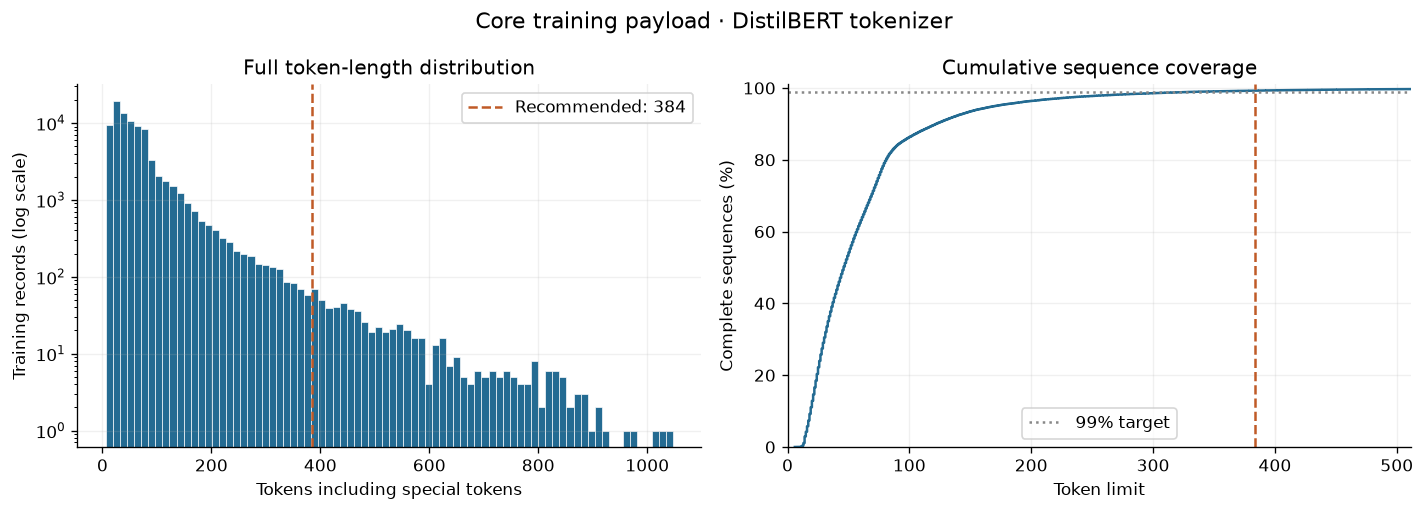

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].hist(core_tokens, bins=80, color="#246B92", edgecolor="white", linewidth=0.4)
axes[0].axvline(recommended_max_length, color="#C05A27", linestyle="--",
                label=f"Recommended: {recommended_max_length}")
axes[0].set_yscale("log")
axes[0].set(title="Full token-length distribution", xlabel="Tokens including special tokens", # special tokens are referring to tokenizers [CLS], [SEP] not including [PAD] or [MASK]
            ylabel="Training records (log scale)")
axes[0].legend()

ordered_lengths = np.sort(core_tokens)
axes[1].plot(ordered_lengths, np.arange(1, len(ordered_lengths) + 1) / len(ordered_lengths) * 100,
             color="#246B92") 
axes[1].axhline(COVERAGE_TARGET * 100, color="#888888", linestyle=":", label="99% target") # 99% of the data should be covered by the recommended max length
axes[1].axvline(recommended_max_length, color="#C05A27", linestyle="--")
axes[1].set(title="Cumulative sequence coverage", xlabel="Token limit", ylabel="Complete sequences (%)",
            xlim=(0, MODEL_LIMIT), ylim=(0, 101))
axes[1].legend()
fig.suptitle("Core training payload · DistilBERT tokenizer", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "token_lengths.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)


In [15]:
provenance_status = "archive hash matches metadata; CSV alignment checked" if source_audit["archive_matches"] else "provisional pending source confirmation"
recommendation_text = (
    f"**Recommendation: max_length={recommended_max_length} ({provenance_status}).** "
    f"Using title + purpose + desc on {len(train):,} training loans, "
    f"this retains {chosen['complete_sequence_percent']:.3f}% of complete sequences. "
    f"{int(chosen['truncated_rows']):,} records need truncation, removing "
    f"{chosen['removed_token_percent']:.3f}% of all counted tokens. "
    "Counts include field labels and special tokens. Analysts 2 and 3 should import the same "
    "build_text_payload() function. Analyst 3 should use this tokenizer revision, truncation=True "
    "and dynamic batch padding. TF-IDF consumes the complete payload rather than BERT-truncated text. "
    "If the feature list, cleaning rules or tokenizer changes, recompute these distributions."
)
display(Markdown(recommendation_text))


**Recommendation: max_length=384 (provisional pending source confirmation).** Using title + purpose + desc on 86,293 training loans, this retains 99.257% of complete sequences. 641 records need truncation, removing 1.618% of all counted tokens. Counts include field labels and special tokens. Analysts 2 and 3 should import the same build_text_payload() function. Analyst 3 should use this tokenizer revision, truncation=True and dynamic batch padding. TF-IDF consumes the complete payload rather than BERT-truncated text. If the feature list, cleaning rules or tokenizer changes, recompute these distributions.

### 5.1 Why the saved run recommends 384

The saved run produces the following trade-off for the core payload:

- **256 tokens:** fits **97.90%** of complete narratives; **1,813** would be truncated. This misses the 99% target.
- **384 tokens:** fits **99.26%**; **641** would be truncated. This is the smallest tested candidate that meets the target.
- **512 tokens:** fits **99.70%**; **263** would be truncated. It preserves another **378** complete narratives, a gain of approximately **0.44 percentage points**, while allowing longer inputs.

The token-length median is **46**, the 95th percentile is **171**, and the 99th percentile is approximately **343**. Most sequences are short, but a small long tail reaches **1,047 tokens**. Even a 512-token input cannot fit every narrative intact. Choosing 384 is a practical starting point under our stated coverage rule, not proof that 384 gives the best accuracy or a measured runtime speedup.

At 384, **0.74% of records are shortened**, while **1.62% of the original tokens are removed**. These figures differ because they measure records and tokens, respectively; long records contribute more tokens. **No loans are dropped.** With the current field order and right-side truncation, the tail of a long description is the part most exposed to removal, so coverage alone does not prove that important meaning is preserved.

### 5.2 How to use the recommendation

For Analyst 3's (Vincent) training batches, use the same tokenizer revision with `truncation=True` and `max_length=384`. Apply **dynamic padding per batch** (`padding=True` on a batch, or a padding data collator). Shorter sequences then match the longest sequence in that batch after truncation; they do not all need to be padded to 384.

Keep the shared `clean_text()` and `build_text_payload()` output **untruncated**. Analyst 2's (Yati) TF-IDF pipeline can use the full text; the transformer-specific cap belongs at tokenization. If `emp_title` is enabled, or the fields, cleaner, or tokenizer change, rerun the length analysis for that exact input.

This recommendation uses training text only. Validation can subsequently confirm coverage with the fixed setting, while the test set remains untouched. The source checksum question still makes the current result provisional.

Reference: [Hugging Face padding and truncation](https://huggingface.co/docs/transformers/main/pad_truncation).


## 6. Optional validation confirmation

Leave this disabled for the initial training EDA. After fixing the preprocessing and recommended limit, enable it to report validation coverage once. It does not retune `max_length` or inspect the test set.


In [16]:
RUN_VALIDATION_CHECK = False
validation_summary = None
if RUN_VALIDATION_CHECK:
    validation = load_original_split(DATA_DIR, split="validation")
    validation_tokens = token_lengths(validation["text_payload"])
    validation_summary = {
        "rows": len(validation),
        "max_length": recommended_max_length,
        "complete_sequence_percent": 100 * float(np.mean(validation_tokens <= recommended_max_length)),
        "truncated_rows": int(np.sum(validation_tokens > recommended_max_length)),
    }
    print(json.dumps(validation_summary, indent=2))
else:
    print("Validation confirmation skipped; recommendation uses training only.")


Validation confirmation skipped; recommendation uses training only.
